# Introduction

The dataset I will be analyzing contains the GDP growth in select financial quarters between 2010 and 2023. The seasonally adjusted rate data is provided by the U.S Bureau of Economic Analysis. The data ranges over Obama's two terms, Trump's first term, and Biden's first term. Major events like COVID are well represented in the data. The three methods I will apply to analyze the data is cubic spline interpolation, degree four polynomial approximation, and linear least squares regression.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [62]:
#GDP growth data

quarters = np.array([1,5,9,13,17,19,22,25,27,28,29,33,37,41,42,43,45,49,54,56])
gdp_growth = np.array([1.7,0.1,2.3,2.7,1.7,5.0,3.0,1.5,3.5,1.8,1.3,2.5,3.1,-5.1,-28.1,33.8,6.3,-1.6,2.4,3.3])

In [78]:
def mse(x,y):
    error = np.mean((x - y)**2)
    return error
def r_sq(x, y):
    ss_total = np.sum((x - np.mean(x))**2)
    ss_residuals = np.sum((x - y)**2)
    return 1 - (ss_residuals / ss_total)

def residuals(y_pred,y_actual):
    residuals = y_actual - y_pred
    return residuals

In [63]:
#All the functions needed to do a natural cubic spline interpolation

#thomas algorithm solves the tridiagonal system

def thomas_algorithm(a, b, c, d):
    """
    Solve the tridiagonal system using the Thomas algorithm.
    a: sub-diagonal elements (length n-1)
    b: main diagonal elements (length n)
    c: super-diagonal elements (length n-1)
    d: right-hand side (length n)
    Returns: solution vector x of length n
    """
    n = len(b) # the length of b gives us the number of unknowns which is the length of the main diagonal
    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    
    #formula for each unknown
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    return x



# the following function intializes a tridiagonal linear system. 
# A,B,C are all part of the tridiagonal system while D is the right hand side matrix
# This linear system is needed for the building of the natural cubic spline
def setup_tridiagonal_matrix(x, y):
    

    n = len(x) #length of data points. The n-2 later on is for the unknown interior knots.

    h = np.diff(x)  # Step sizes between data points

    # Initialize the tridiagonal matrix coefficients

    A = np.zeros(n - 2)  # Subdiagonal
    B = np.zeros(n - 2)  # Main diagonal
    C = np.zeros(n - 2)  # Superdiagonal
    D = np.zeros(n - 2)  # Right-hand side vector

    # Populate the tridiagonal matrix coefficients

    for i in range(1, n - 1):

        A[i - 1] = h[i-1]             # Subdiagonal
        B[i - 1] = 2 * (h[i-1]+h[i])            # Main diagonal
        C[i - 1] = h[i]             # Superdiagonal
        D[i - 1] = 6 * ((y[i + 1]-y[i]) / h[i]-(y[i]-y[i-1])/h[i-1])             # Right-hand side vector

    return A, B, C, D


#the spline is evaluated at any point along the int
def eval_spline(X,Y):
    
    A, B, C, D = setup_tridiagonal_matrix(X, Y)
    M = np.array([0.0, * thomas_algorithm (A, B, C, D), 0.0], dtype=float)
    
    n = 0
    for i in range(len(X)-1):
        n = n + ((X[i+1]-X[i]) * 100)
    
    X2 = np.linspace(X[0],X[len(X)-1],int(n))
    Y2 = np.zeros(int(n))
    
    dx_i = 0  # initializing a variavble to track the cumaltive delta x for easy indexing
    
    for i in range(len(X) - 1):
        h = X[i+1] - X[i]

        num_points = int(h * 100)
        X_interpolate = np.linspace(X[i], X[i+1], num_points, endpoint=False)

        term1 = (M[i] / (6 * h)) * (X[i+1] - X_interpolate)**3
        term2 = (M[i+1] / (6 * h)) * (X_interpolate - X[i])**3
        term3 = (Y[i] / h - (M[i] * h) / 6) * (X[i+1] - X_interpolate)
        term4 = (Y[i+1] / h - (M[i+1] * h) / 6) * (X_interpolate - X[i])

        total = term1 + term2 + term3 + term4

        Y2[dx_i:dx_i + num_points] = total
        dx_i += num_points

    return X2, Y2

With our data set having 20 data points, there are 18 unknown second derivatives that the functions solve for in order to construct the spline. The system of equations is composed of a tridiagonal matrix and two column vectors. The system's tridiagonal nature is a result of each point's equation only invovles its 2 neighboring points in the interpolation. The system is built with the setup_tridiagonal_matrix, solved using the Thomas algorithm by finding the unknown second derivatives, and then used in the eval_spline function to construct the piecewise cubic spline.

At each interior knot, the spline must satisfy three conditions of continuity. The first one is that the curve itself must be continous. The second one is that the first derivatives of the curve must be continous. The last one is that the second derivatives of the curve must also be continous throughout. Altogether, these continuity conditions ensure that the cubic spline is smooth throughout and allows it to resemble the tendencies of mathematical functions.

The boundary conditions for the boundary splines are that the second derivatives at that point are equal to 0.  

In [ ]:
#check condition

#np.linalg.cond()

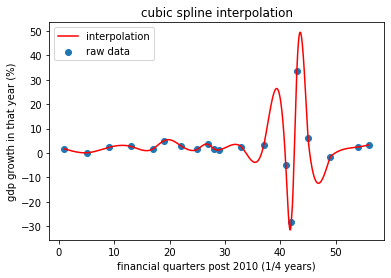

In [99]:
#calling the cubic spline function and thoroughly plotting

x_spline, y_spline = eval_spline(quarters,gdp_growth)

plt.figure()
plt.scatter(quarters,gdp_growth, label = "raw data")
plt.plot(x_spline,y_spline, color = "red", label = "interpolation")
plt.xlabel("financial quarters post 2010 (1/4 years)")
plt.ylabel("gdp growth in that year (%)")
plt.title("cubic spline interpolation")
plt.legend()
plt.show()

The cubic spline interpolation seems to be very visually smooth and reasonable. The interpolation passes through every data point, accurately representing the entirety of the data set. R-squared and MSE aren't exactly applicable here as the data is perfectly fit. Its effort to capture the COVID outliers are well represented as the bending of the curves become very steep in order to catch the data points in this region. Even with these sharp bends, the cubic spline is stable as its method of evaluation is more local than other methods.

The Runge Phenomenon refers to the extreme oscillations that occurs for models like this when extreme outliers are present and the continuity condition is enforced, requiring the model to run through all data points. The Runge phenomenon is well displayed in the cubic spline as there are very large oscillations when the spline is attempting to represent the COVID outliers, resulting in an overfitting of the data. In cases like this, a tradeoff between numerical stability and exact interpolation exists. The extreme oscillations prove the model to be numerically unstable but it does provide exact interpolation, showing that there are tradeoffs to this model depending on the use-case of it. The natural cubic spline would be a great option in cases where exact interpolation is a priority. 

If the goal of the study was to find a model that would exactly interpolate the data points, the cubic spline model I just employed would be the best option. However, smoothing splines or weighted least squares would be preferable here if the goal of the study was to have a model that shows the general trend and has numerical stability. Specifically, using weighted least squares would be a better option if the goal was to capture the general trend as the nature of the method assigns lower weights to extreme outliers. Even smoothing splines can help capture the general trend of the data better than the natural cubic spline as the smoothing parameter implimented in the smoothing splines will penalize extreme changes in the curvature while the natural spline doesn't penalize this. These two models do a better job of resisting the influence of the outliers and give a more wholistic view of the data rather than responding to individual extremes like my cubic spline model.

In [101]:
#functions for polynomial fitting. 
#Vandermonde matrix is generated first and used in polynomial approx function which returns the coefficients of the polynomial.

def vandermonde_matrix(x,degree):
    n = len(x)
    V = np.zeros((n, degree + 1))
    for i in range(n):
        for j in range(degree + 1):
            V[i][j] = x[i] ** j
    return V

def polynomial_approx(x,y,degree):
    V = vandermonde_matrix(x, degree)
    vander_condition = np.linalg.cond(V)
    print(f"The condition of the Vandermonde matrix is {vander_condition}. This is well below the 10^12 threshold")
    VT_V = np.dot(V.T, V)
    VT_y = np.dot(V.T, y)
    cfs = np.linalg.solve(VT_V, VT_y)
    return cfs

The condition of the Vandermonde matrix is 18197798.18154116. This is well beloew the 10^12 threshold


Text(0.5, 1.0, 'Residual plot for the linear least squares regression')

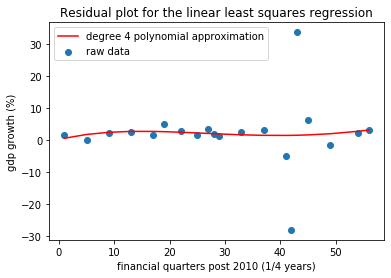

In [100]:
#creating the actual function and thoroughly plotting

degree=4
cfs = polynomial_approx(quarters,gdp_growth,degree)
y_poly_approx = 0

for i in range (degree + 1):
    y_poly_approx += cfs[i] * (quarters**i)

plt.scatter(quarters,gdp_growth,label = "raw data")
plt.plot(quarters,y_poly_approx, color = "red", label = "degree 4 polynomial approximation")
plt.xlabel("financial quarters post 2010 (1/4 years)")
plt.ylabel("gdp growth (%)")
plt.legend()
plt.title("Residual plot for the linear least squares regression")


Text(0.5, 1.0, 'comparing cubic spline and polynomial approximation')

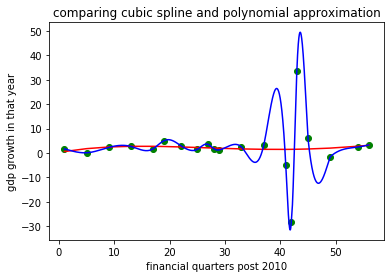

In [67]:
#plotting both methods

plt.scatter(quarters,gdp_growth,color = "green")
plt.plot(quarters,y_poly_approx,color = "red", label = "polynomial_approx")
plt.plot(x_spline,y_spline, color = "blue", label = "cubic spline")
plt.xlabel("financial quarters post 2010 (1/4 years)")
plt.ylabel("gdp growth (%)")
plt.title("comparing cubic spline and polynomial approximation")



 The mean squared error value is 100.62980208981799
 The r squared error value is 0.0035410151185396588


Text(0.5, 1.0, 'Residual plot for the degree four polynomial approximation')

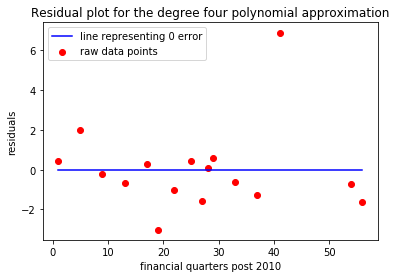

In [98]:
#getting residuals, mse, and r squared.
# plotting residual plot

res_poly = residuals(y_poly_approx,quarters)

zero_error_line_poly = np.zeros(len(quarters))

mse_error = mse(gdp_growth,y_poly_approx)
print(f" The mean squared error value is {mse_error}")
r_squared = r_sq(gdp_growth,y_poly_approx)
print(f" The r squared error value is {r_squared}")

plt.scatter(no_Covid_quarters,res, color = "red", label = "raw data points")
plt.plot(no_Covid_quarters,zero_error_line, color = "blue", label = "line representing 0 error")
plt.xlabel("financial quarters post 2010 (1/4 years)")
plt.ylabel("residuals (%)")
plt.legend()
plt.title("Residual plot for the degree four polynomial approximation")

In [68]:
#creating no COVID data set
no_Covid_quarters = np.append(quarters[0:14],quarters[18:])
no_Covid_gdp_growth = np.append(gdp_growth[0:14],gdp_growth[18:])

In [75]:
#least squares function producing m and c
def lst_sq_reg (x,y):
    n = len(x)
    x_sum = np.sum(x)
    y_sum = np.sum(y)
    x_sum2 = np.sum(x**2)
    xy_sum= np.sum(x * y)
    m = (n*xy_sum - x_sum * y_sum) / (n * x_sum2 - x_sum**2)
    c = (y_sum - m*x_sum) / n
    return m, c

 The least squares slope is -0.008049946865037213
 The mean squared error value is 4.4241304131243355
 The r squared error value is 0.003433948894982608


Text(0.5, 1.0, 'Combined plot for the cubic spline and the linear least squares regression')

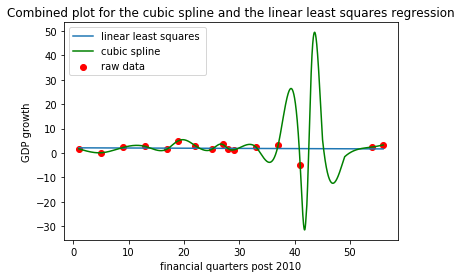

In [97]:
#getting m and c and creating interpolated line. 
#mse, r squared and plotting

m1, c1 = lst_sq_reg(no_Covid_quarters,no_Covid_gdp_growth)
print(f" The least squares slope is {m1}")
y_ls = m1 * no_Covid_quarters + c1
mse_error = mse(no_Covid_gdp_growth,y_ls)
print(f" The mean squared error value is {mse_error}")
r_squared = r_sq(no_Covid_gdp_growth,y_ls)
print(f" The r squared error value is {r_squared}")

plt.scatter(no_Covid_quarters,no_Covid_gdp_growth, color= "red", label = "raw data")
plt.plot(no_Covid_quarters,y_ls, label = "linear least squares " )
plt.plot(x_spline,y_spline, color = "green", label = "cubic spline")
plt.xlabel("financial quarters post 2010 (1/4 years)")
plt.ylabel("GDP growth (%)")
plt.legend()
plt.title("Combined plot for the cubic spline and the linear least squares regression")

Text(0.5, 1.0, 'Residual plot for the linear least squares regression')

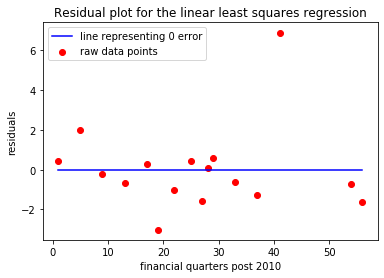

In [95]:
#residual plotting

res = residuals(y_ls,no_Covid_gdp_growth)

zero_error_line = np.zeros(len(no_Covid_quarters))

plt.scatter(no_Covid_quarters,res, color = "red", label = "raw data points")
plt.plot(no_Covid_quarters,zero_error_line, color = "blue", label = "line representing 0 error")
plt.xlabel("financial quarters post 2010 (1/4 years)")
plt.ylabel("residuals (%)")
plt.legend()
plt.title("Residual plot for the linear least squares regression")

# Part B

The degree four polynomial interolation captures the overall trend much better than the cubic spline interpolation due to its resistance to outlier influence. However, the cubic spline interpolation does a far better job of reproducing the specific data points, particularly because of the imposed continuity conditions. 

The tradeoffs between the two methods of approximation are clear. While the cubic spline interpolation allows for the data set to be completely represented, it does a poor job of representing the general trend in the data and is heavily influenced in the prescence of outliers. The continuity conditions are part of the reason for this as the spline ends up having extreme oscillations in order to satisfy continuity throughout all the data points. On the other hand, the polynomial approximation does a good job of capturing the general trend, resisting the influence of outliers and sticking to a more global movement of the data points. However, for many of the same reasons it does a good job capturing the overall trend of the data points, it does a poor job of representing each of the individual data points. Due to its inability to represent the outliers effectively, the underfitting and high error of the interpolation is showed in the r squared and mean squared error values. The global approach it takes to the data makes it such that it doesn't make huge deviations from the general trend in order for it to capture the outliers.



The linear trend doesn't really make any sense for this data. In general, a linear trend is not realistic for GDP growth as it is highly dependent on the economic conditions during a given quarter which no clear pattern as to when favorable conditions and unfavorable conditions are present. Wars begin and end at unpredictable times, innovation comes and goes at unpredicatble times, and these things are factors of GDP growth that come at random times which results in more of a cyclical pattern of GDP growth rather than a strictly linear pattern. The reported slope from the method is next to 0. This could have implications that there wasn't much movement in GDP growth across the entire time frame which is not necessarily true. This shows no representation of the cyclical economy of the US. In addition to this, the r squared value is very low and the mean squared error is very high, showing that the linear interpolation does a very poor job of fitting the data points and that there is a lot of error between the data points and the interpolation.



In order for a linear model to make sense, we must make the assumption that there will be some driving factor in the economy to either drive the year-after-year GDP growth up or down. Only then could a linear model make sense because the slope of the model can be explained by the driving factor in the economy.

# Part C

For a policy maker who needs to estimate GDP growth for a quarter, which method is recommended
Reference smoothness, accuracy, and sensitivity to outliers

For a policymaker who needs to estimate GDP growth between two known data points, I would reccomend the use of the cubic spline interpolation. Since the policy maker is at a very local scale as he/she is only dealing with 2 data points, I would place a big priority on accuracy and a lesser priority on smoothness. In this case, accurately representing the data is critical for the purpose of the policy maker and the cubic spline interpolation is far more accurate than the polynomial interpolation. While the polynomial approximation interpolation has non-zero residuals and extremely significant residuals during the COVID years, the residuals for the cubic spline are essentially zero, signifying a perfect fit of the data and the superior choice for estimating growth between two known quarters. Additionally, due to the continuity of the cubic spline itself, its first derivative, and its second derivative, it produces a very smooth curve, providing a realistic interpolation of the regions in between the data points. While the cubic spline is extremely sensitive to outliers, this would only pose a major red flag in the case of seeking a general/overall trend in the data. The sensitivity to outliers here is another reason to use cubic spline in this situation as its ability to adjust to outliers and keep continuity throughout derivatives 0-2 allows the policy maker to estimate GDP growth accurately through outlier years like the COVID years.


(The following paragraph is not specifically the answer to question in the instructions but I felt it was important to note)

However, for a policy maker who needs to estimate GDP growth a random quarter or the next quarter (a case in which the data points are unknown, I would reccomend using the degree 4 polynomial approximation method as it takes the best of both worlds in my opinion. I believe that policy makers should look at estimating GDP growth for a quarter from a very global point of view. It is next to impossible to be able to predict the timing and the nature of these global events causing outliers in our GDP growth. Therefore, I believe that capturing the overall trend is the highest priority, especially in the eyes of a policy maker. In terms of smoothness, the polynomial apporximation isn't as smooth as the cubic spline interpolation with the spline interpolation capturing every point in the data set with continous first and second derivatives.  Even the spline is a more accurate method as there are essentially zero residuals. However, I believe that the polynomial approximation is still an accurate method as it manages to run through several data points and the residuals between the actual data point and the polynomial approximation until the outlier quarters. Lastly, the polynomial approximation is far less sensitive to outliers, preventing erratic behavior unlike the cubic spline approximation. Like I've previously mentioned, the policy maker would be better off using an estimation that is almost perfectly accurate over using a method in which outliers cause extreme changes in the interpolation. 


The Big O notation is something that describes the time or computational cost it takes to run a given algorithm, growing proportionally with the size of the input. Nested for loops are a perfect example of the big O notation. A single for loop only depends on the size n of the for loop. However, a double for loop would now follow an n^2 trend, making it a lot more computationally expensive.

The big O for the cubic spline would be O(n) as there are plenty of for loops but none of them being nested. For this reason, it is still relatively cheap computationally. The big O for the polynomial approximation is O(n^2) as there is a nested for loop in the Vandermonde matrix. In this case, the big O would grow to be a lot higher than the big O for the cubic spline when the number of data points keep increasing.

This reaffirms my decision to use cubic spline in the case of the policy maker estimating GDP between two known points. In addition to the points I had earlier laid out, the cubic spline interpolation is much more scalable to larger data sets as its big O grows linearly compared to the positive-quadratic nature of the polynomial approximation big O. As the policy maker wishes to use larger datasets, they aren't sacrificing as much computational power as the polynomial approximation does.

# Conclusion

To conclude, the methods I implimented taught me a lot about the advantages and limitations of these methods. For things such as general trend analysis, methods like polynomial approximation and linear least squares regression were a much better choice due to its ability to resist the influence of outliers, specifically during the COVID years in our dataset. However, it was limited in accurate interpolation of  the data as the r squared value was really low and the mean squared value was really high for the two methods, showing a poor job to fit the data with a lot of error. On the other hand, the cubic spline did an excellent job with its interpolation accuracy as it had next to no residuals and captured each and every data point. However, it did a poor job with general trend analysis as it would be compelled to enforce continuity throughout which resulted in huge oscillations at these outliers (Runge's phenomenon). Overall, this taught me that there is an intricate decision to be made about what method to use when analyzing data. This decision is mainly predicated on the goal of the study one is performing as each method has its own advantages and disadvantages.